# E07 · Geo-temporal modelling: induced earthquakes in Oklahoma

| | |
|---|---|
| **Type** | Advanced worked example - read, run, modify |
| **Data** | USGS catalogue of every magnitude 3+ earthquake in and around Oklahoma, 2005-2019 (2917 events) |
| **You will learn** | Turning a point catalogue into a space x time count array · the log-Gaussian Cox process (LGCP) · why LGCP priors explode through the `exp` link and how separating *how many* from *where* tames them · a 2-D `pm.gp.HSGP` spatial field: `m`, `c` and a lengthscale prior in kilometres · a space-time **interaction**: a spatial field whose basis coefficients follow a random walk · overdispersion and `NegativeBinomial` · spatial and temporal posterior predictive checks · LOO across a model ladder · forecasting a held-out period, and what such a forecast cannot know |

For 2005-08 this catalogue lists one to three magnitude-3+ earthquakes a year in and around
Oklahoma. For 2015 it lists more than nine hundred. The surge is widely attributed to the
deep disposal of wastewater from oil and gas production, and it receded after regulators
limited injection volumes in 2015-16. The earthquakes did not rise and fall everywhere at once: the active
area *moved*.

This notebook asks three questions of the catalogue alone:

1. **Where and when** was the earthquake rate elevated?
2. **How did the hot-spot move?**
3. What does the model **forecast for a held-out final period** (2018-19), and how much of
   that forecast deserves to be believed?

It builds on **E05**: you should already know what an HSGP is, what `m` and `c` do, and why
centred and non-centred coefficients behave differently. Here the GP becomes two-dimensional,
gets a time axis, and sits behind a count likelihood.

In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import preliz as pz
import pymc as pm
import pytensor.tensor as pt
import xarray as xr
from matplotlib.colors import LogNorm
from pymc.gp.hsgp_approx import calc_eigenvalues, calc_eigenvectors
from scipy import stats
from scipy.special import logsumexp

from pymc_challenges import data

RANDOM_SEED = 2016
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")

print(f"PyMC {pm.__version__}, ArviZ {az.__version__}, PreliZ {pz.__version__}")

PyMC 6.3.2, ArviZ 1.3.0, PreliZ 0.28.0


## 1 · Question and data

In [2]:
data.describe("oklahoma_quakes")
quakes = data.load("oklahoma_quakes")
quakes[["time", "latitude", "longitude", "depth", "mag", "place"]].tail(3)

oklahoma_quakes: Every magnitude 3+ earthquake in and around Oklahoma, 2005-2019: time, location, depth, magnitude.
  source: USGS ComCat earthquake catalogue (FDSN event web service).
  url:    https://earthquake.usgs.gov/fdsnws/event/1/query?format=csv&starttime=2005-01-01&endtime=2020-01-01&minmagnitude=3&minlatitude=33.6&maxlatitude=37.1&minlongitude=-100.1&maxlongitude=-94.4&orderby=time-asc


,time,latitude,longitude,depth,mag,place
2914,2019-12-15 16:09:05.679000+00:00,35.799000,-96.654667,7.09,3.59,"5 km N of Stroud, Oklahoma"
2915,2019-12-25 11:24:33.350000+00:00,35.907333,-98.523167,7.53,3.38,"12 km NW of Watonga, Oklahoma"
2916,2019-12-30 05:57:55.689000+00:00,36.874333,-97.913333,7.35,3.73,"1 km SE of Wakita, Oklahoma"


In [3]:
per_year = quakes.groupby(quakes.time.dt.year).size()
print(per_year.to_string())

time
2005      1
2006      3
2007      1
2008      2
2009     20
2010     41
2011     63
2012     34
2013    103
2014    591
2015    914
2016    643
2017    275
2018    166
2019     60


Seven events in the four years 2005-08, then 20, 41, 63 ... 914 in 2015, and back down to
60 in 2019. The largest events give a first idea of the geography:

In [4]:
quakes.nlargest(5, "mag")[["time", "mag", "latitude", "longitude", "place"]]

,time,mag,latitude,longitude,place
2256,2016-09-03 12:02:44.400000+00:00,5.8,36.4251,-96.9291,"14 km NW of Pawnee, Oklahoma"
86,2011-11-06 03:53:10+00:00,5.7,35.5320,-96.7650,"8 km NW of Prague, Oklahoma"
1910,2016-02-13 17:07:06.290000+00:00,5.1,36.4898,-98.7090,"18 km SE of Waynoka, Oklahoma"
2364,2016-11-07 01:44:24.500000+00:00,5.0,35.9907,-96.8030,"3 km W of Cushing, Oklahoma"
79,2011-11-05 07:12:45+00:00,4.8,35.5500,-96.7640,"8 km SE of Sparks, Oklahoma"


## 2 · From a catalogue to a space x time count array

A point process model needs three pieces of data engineering, and each involves a choice
that ends up in the results, so we make them in the open.

**Project to kilometres.** A GP lengthscale in degrees means different distances east-west
and north-south. With no GIS stack in this environment we use an *equirectangular*
projection about a reference point $(\lambda_0, \varphi_0)$,

$$x = R\,\cos\varphi_0\,(\lambda - \lambda_0), \qquad y = R\,(\varphi - \varphi_0),$$

with longitudes and latitudes in radians and $R = 6371$ km. It ignores the convergence of
the meridians; the cell below prints how much that matters over our window.

In [5]:
LON0, LAT0 = -97.8, 36.1  # reference point: the middle of the active area
KM_PER_DEG = np.deg2rad(1) * 6371.0


def project(lon, lat):
    """Equirectangular projection to kilometres east / north of (LON0, LAT0)."""
    x = (np.asarray(lon) - LON0) * KM_PER_DEG * np.cos(np.deg2rad(LAT0))
    y = (np.asarray(lat) - LAT0) * KM_PER_DEG
    return x, y


quakes["x"], quakes["y"] = project(quakes.longitude, quakes.latitude)

for lat in (LAT0 - 1, LAT0 + 1):
    stretch = np.cos(np.deg2rad(lat)) / np.cos(np.deg2rad(LAT0))
    print(f"at latitude {lat:.1f} a true east-west km is drawn as {1 / stretch:.3f} km")

at latitude 35.1 a true east-west km is drawn as 0.988 km
at latitude 37.1 a true east-west km is drawn as 1.013 km


About 1% of distortion at the northern and southern edges: irrelevant next to 25 km cells.

**Choose a window and a grid.** The catalogue covers a box from Texas to Kansas, but most
of it is empty. We model a 300 km x 225 km window around the active area with **25 km
cells** (12 x 9 = 108 cells), and **quarters** as the time unit. Smaller cells would give
prettier maps and mostly-zero data; bigger cells would blur hot-spots that are only a few
tens of km across. The clock starts in 2009, when the rate first lifts off.

**Hold out the end.** 2009-2017 (36 quarters) is training data; 2018-2019 (8 quarters) is
never shown to any model and is used once, in section 10.

In [6]:
CELL = 25.0
x_edges = np.arange(-150, 150 + CELL, CELL)
y_edges = np.arange(-112.5, 112.5 + CELL, CELL)
nx, ny = len(x_edges) - 1, len(y_edges) - 1
n_cell = nx * ny

periods = pd.period_range("2009Q1", "2019Q4", freq="Q")
period_labels = periods.astype(str).to_numpy()
year_of_period = periods.year.to_numpy()
years = np.unique(year_of_period)
n_period, n_era = len(periods), len(years)
n_train = int((year_of_period <= 2017).sum())

in_window = (quakes.x.between(x_edges[0], x_edges[-1], inclusive="left")
             & quakes.y.between(y_edges[0], y_edges[-1], inclusive="left"))
in_time = quakes.time.dt.year >= 2009
events = quakes[in_window & in_time].copy()
print(f"{in_time.sum()} events since 2009, {len(events)} of them inside the window "
      f"({len(events) / in_time.sum():.1%})")

# cell id = row * nx + column, rows counted from the south
col = np.floor((events.x - x_edges[0]) / CELL).astype(int)
row = np.floor((events.y - y_edges[0]) / CELL).astype(int)
events["cell"] = row * nx + col
events["period"] = (events.time.dt.year - 2009) * 4 + events.time.dt.quarter - 1

count_array = np.zeros((n_cell, n_period), dtype=int)
np.add.at(count_array, (events.cell.to_numpy(), events.period.to_numpy()), 1)

xc, yc = (x_edges[:-1] + x_edges[1:]) / 2, (y_edges[:-1] + y_edges[1:]) / 2
cell_xy = np.column_stack([np.tile(xc, ny), np.repeat(yc, nx)])  # (n_cell, 2), km

counts = xr.DataArray(
    count_array, dims=("cell", "period"),
    coords={"cell": np.arange(n_cell), "period": period_labels, "year": ("period", year_of_period),
            "x": ("cell", cell_xy[:, 0]), "y": ("cell", cell_xy[:, 1])},
)
y_train, y_test = counts.isel(period=slice(0, n_train)), counts.isel(period=slice(n_train, None))

print(f"count array {counts.shape}: {n_cell} cells x {n_period} quarters; "
      f"{int(y_train.sum())} training events, {int(y_test.sum())} held out")
print(f"training array: {float((y_train == 0).mean()):.1%} zeros, largest count {int(y_train.max())}, "
      f"mean {float(y_train.mean()):.2f}, variance {float(y_train.var()):.1f}")

2910 events since 2009, 2852 of them inside the window (98.0%)
count array (108, 44): 108 cells x 44 quarters; 2644 training events, 208 held out
training array: 86.2% zeros, largest count 86, mean 0.68, variance 9.4


From here on everything carries the dims `("cell", "period")`. An xarray `DataArray` makes
the bookkeeping trivial: `counts.sum("cell")` is the time series, `counts.groupby("year")`
the yearly maps.

Now some plotting helpers. We have no basemap, so a handful of towns provide orientation.
Their coordinates agree with the catalogue's own `place` strings ("3 km W of Cushing").

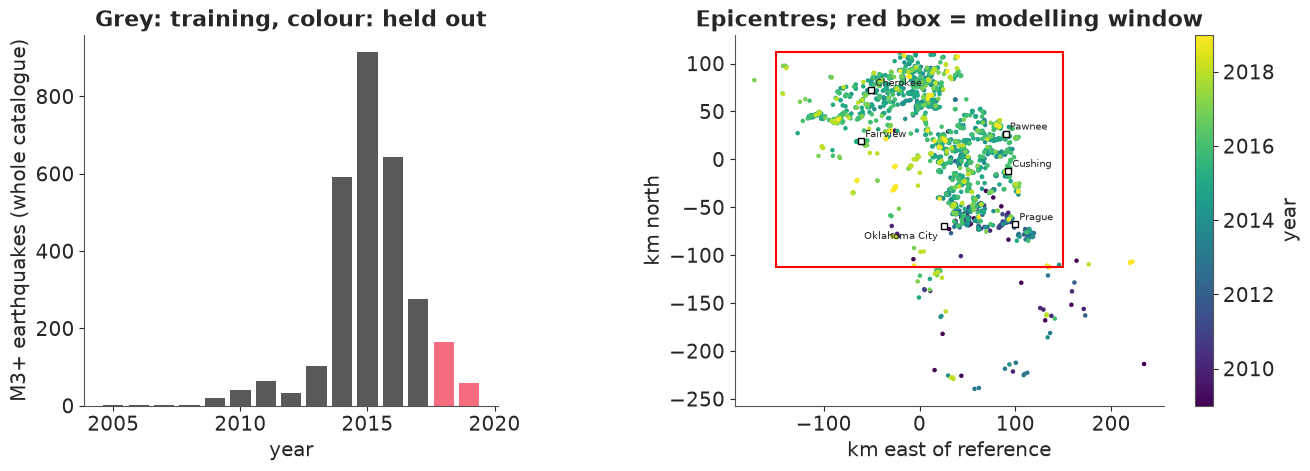

In [7]:
TOWNS = {"Oklahoma City": (-97.52, 35.47), "Prague": (-96.69, 35.49), "Cushing": (-96.77, 35.99),
         "Pawnee": (-96.80, 36.34), "Fairview": (-98.48, 36.27), "Cherokee": (-98.36, 36.75)}


def add_towns(ax, labels=True):
    for name, (lon, lat) in TOWNS.items():
        tx, ty = project(lon, lat)
        ax.plot(tx, ty, marker="s", ms=4, mfc="w", mec="k", ls="none", zorder=5)
        if labels:
            left = name == "Oklahoma City"  # keep its label clear of Prague's
            ax.annotate(name, (tx, ty), xytext=(-4, -9) if left else (3, 3), textcoords="offset points",
                        ha="right" if left else "left", fontsize=7.5, zorder=6)


def draw_map(ax, values, title=None, norm=None, cmap="magma_r", labels=False, pts=None):
    """Colour the 12 x 9 grid by `values` (length n_cell); optionally overlay events."""
    mesh = ax.pcolormesh(x_edges, y_edges, np.asarray(values).reshape(ny, nx), norm=norm, cmap=cmap)
    if pts is not None:
        ax.scatter(pts.x, pts.y, s=4, color="dodgerblue", alpha=0.6, lw=0)
    add_towns(ax, labels=labels)
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=10)
    ax.set(xticks=[], yticks=[])
    return mesh


COUNT_NORM = LogNorm(vmin=0.3, vmax=300)  # shared colour scale: events per cell per year


def faint_to_blank(values):
    """Mask cells below the colour scale (fewer than 0.3 events a year) so that they stay white."""
    return values.where(values >= COUNT_NORM.vmin)


fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), width_ratios=[1, 1.5])
axes[0].bar(per_year.index, per_year.values, color=["0.35" if y <= 2017 else "C1" for y in per_year.index])
axes[0].set(xlabel="year", ylabel="M3+ earthquakes (whole catalogue)", title="Grey: training, colour: held out")
sc = axes[1].scatter(quakes.x, quakes.y, c=quakes.time.dt.year, s=5, cmap="viridis", vmin=2009, vmax=2019)
axes[1].add_patch(plt.Rectangle((x_edges[0], y_edges[0]), 300, 225, fill=False, ec="red", lw=1.5))
add_towns(axes[1])
axes[1].set(xlabel="km east of reference", ylabel="km north", title="Epicentres; red box = modelling window")
axes[1].set_aspect("equal")
fig.colorbar(sc, ax=axes[1], label="year");

The colours already tell the story of question 2: the early (dark) events sit in the
south-east around Prague and Oklahoma City, the later (green-yellow) ones further north
and west. The sharp upper edge is **not geology**: the catalogue query stops at latitude
37.1, just north of the Kansas border, and our window stops with it. Whatever the model
says about the northernmost row of cells is about a truncated hot-spot.

The same thing as the model will see it - counts per cell, for six of the nine training
years, on a logarithmic colour scale (white cells are empty):

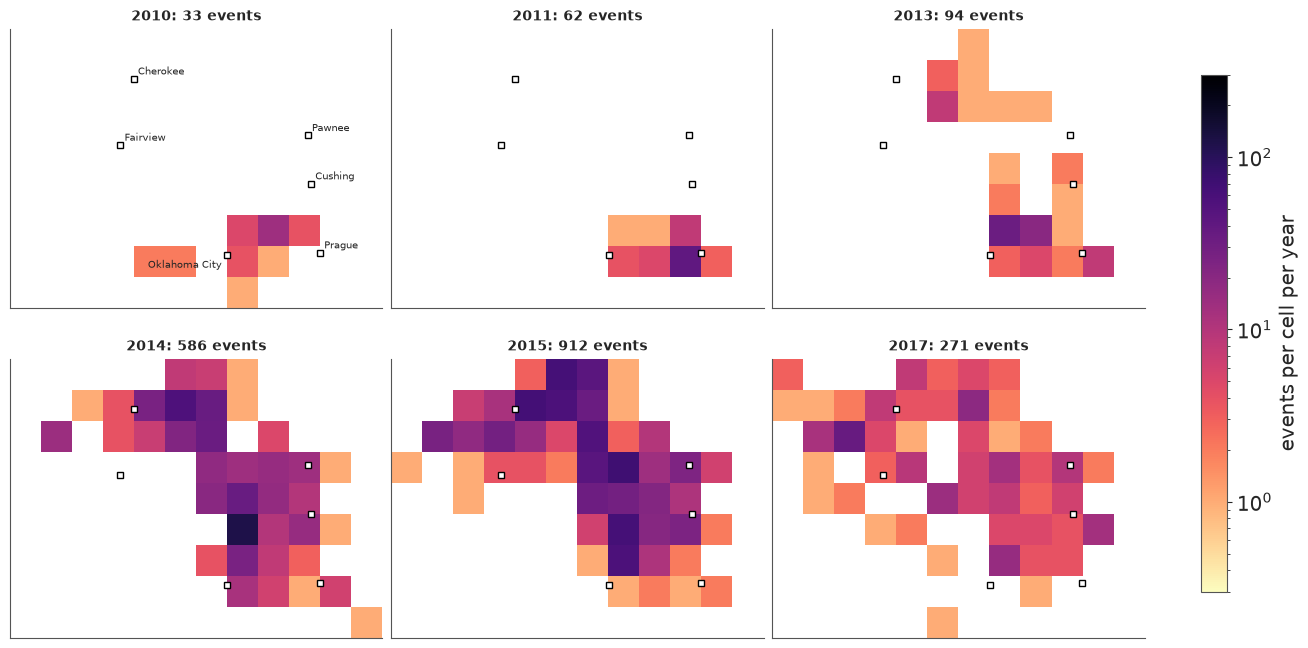

In [8]:
yearly = counts.groupby("year").sum()

fig, axes = plt.subplots(2, 3, figsize=(13, 6.6))
for ax, year in zip(axes.flat, [2010, 2011, 2013, 2014, 2015, 2017]):
    obs = yearly.sel(year=year)
    mesh = draw_map(ax, faint_to_blank(obs), f"{year}: {int(obs.sum())} events", COUNT_NORM,
                    labels=(year == 2010))
fig.colorbar(mesh, ax=axes, label="events per cell per year", shrink=0.8);

In 2010 there is a small patch east of Oklahoma City; 2011 is dominated by the
magnitude-5.7 Prague sequence in the south-east; 2013 adds a separate patch near the Kansas
border; by 2014-15 activity fills a band from Oklahoma City to the border, with an arm
reaching west past Cherokee; by 2017 the map is dimmer nearly everywhere. A model whose
spatial pattern cannot change over time has no chance.

## 3 · The model family: a log-Gaussian Cox process

A **Poisson process** with intensity $\lambda(s, t)$ (events per km² per unit time) says that
counts in disjoint regions of space-time are independent Poisson variables whose means are
the integrals of $\lambda$. A **Cox process** makes $\lambda$ itself random, and a
**log-Gaussian** Cox process gives $\log\lambda$ a Gaussian-process prior. On our grid, with
$\lambda$ treated as constant within a cell and a quarter,

$$y_{ct} \sim \text{Poisson}(\lambda_{ct}), \qquad
\log\lambda_{ct} = \alpha + g_t + f(s_c) + h(s_c, t),$$

where $g$ is a temporal component, $f$ a smooth spatial field evaluated at the cell centre
$s_c$, and $h$ a space-time interaction. The grid is a quadrature rule, not part of the
model: $f$ is a function on the plane. We climb a ladder:

| rung | $\log\lambda_{ct}$ | what it can express |
|---|---|---|
| 1 | $\alpha + g_t$ | the rise and fall, same everywhere |
| 2 | $\alpha + g_t + f(s_c)$ | a fixed map, scaled up and down in time (**separable**) |
| 3 | $\alpha + g_t + f_{\text{year}(t)}(s_c)$ | a map that **moves** |
| 4 | rung 3 with a `NegativeBinomial` likelihood | ... and clustered events |

### The spatial field: a 2-D HSGP

Everything from E05 carries over; the basis functions become products of sines,
$\phi_{jk}(x, y) = \phi_j(x)\,\phi_k(y)$, and `m=[m_x, m_y]` sets how many per axis. The
number of basis functions is the **product** $m_x m_y$, which is why HSGP stops being
attractive beyond two or three dimensions.

**Lengthscale prior, in km.** The geography brackets it. The blobs on the maps above are
one to three cells across, which points at lengthscales of a few tens of km. Much below
the 25 km cell width a field is indistinguishable from independent cell effects, and a
lengthscale above 100 km - a third of the window - would make the whole active area one
smooth hump. As in E05 we ask PreliZ for the maximum-entropy inverse-gamma with 90% of its
mass between 15 and 100 km, and print what the lower end means on this grid:

In [9]:
ell_prior = pz.maxent(pz.InverseGamma(), lower=15, upper=100, mass=0.9, plot=False)
ELL_ALPHA, ELL_BETA = float(ell_prior.alpha), float(ell_prior.beta)
print(ell_prior, f"  median = {ell_prior.ppf(0.5):.0f} km,  P(ell < 15 km) = {ell_prior.cdf(15):.3f},  "
      f"P(ell > 100 km) = {1 - ell_prior.cdf(100):.3f}")
for ell_km in (15, 50):
    corr = pm.gp.cov.Matern52(1, ls=ell_km)(np.array([[0.0], [CELL]])).eval()[0, 1]
    print(f"ell = {ell_km} km: correlation between neighbouring cell centres = {corr:.2f}")

InverseGamma(alpha=3.97, beta=170)   median = 47 km,  P(ell < 15 km) = 0.004,  P(ell > 100 km) = 0.096
ell = 15 km: correlation between neighbouring cell centres = 0.23
ell = 50 km: correlation between neighbouring cell centres = 0.83


At $\ell = 15$ km neighbouring cells are still correlated, but only just: the grid has
little to say about anything shorter, and the inverse-gamma's thin left tail keeps the
sampler out of that region.

**Choosing `m` and `c`.** E05's heuristic `approx_hsgp_hyperparams` is built for one
dimension, where basis functions are cheap. Here we are under a hard constraint: in rung 3
every basis function gets one coefficient **per year**, so the parameter count is
$m_x m_y \times 11$. So we reason directly:

- The cell centres are 25 km apart, so the grid cannot see wavelengths below 50 km. Basis
  function $j$ has wavelength $4L/j$; anything much finer than 50 km is wasted.
- `c` sets the boundary $L = c \times$ half-range. Too small and the field is pinched to
  zero at the window's edge - right where the northern hot-spot is.

The table compares the exact Matern-5/2 covariance between cell centres with its HSGP
approximation: the lowest prior variance of any cell (it should be 1; low values mean a
pinched edge) and the largest error anywhere in the covariance matrix.

In [10]:
half_range = (cell_xy.max(0) - cell_xy.min(0)) / 2
cell_xy_centred = cell_xy - (cell_xy.max(0) + cell_xy.min(0)) / 2
rows = []
for m_try, c_try in [([10, 8], 1.3), ([14, 10], 1.5), ([20, 16], 2.0)]:
    L = c_try * half_range
    eigvals = calc_eigenvalues(L, m_try)
    phi_np = calc_eigenvectors(cell_xy_centred, L, eigvals, m_try)
    phi_np = phi_np.eval() if hasattr(phi_np, "eval") else np.asarray(phi_np)
    for ell_km in [25, 35, 50, 100]:
        cov = pm.gp.cov.Matern52(2, ls=ell_km)
        psd = cov.power_spectral_density(np.sqrt(eigvals)).eval().ravel()
        K_approx, K_true = phi_np @ np.diag(psd) @ phi_np.T, cov(cell_xy).eval()
        rows.append({"m": str(m_try), "c": c_try, "basis functions": int(np.prod(m_try)),
                     "finest wavelength (km)": round(4 * L[0] / m_try[0]), "ell (km)": ell_km,
                     "min var": np.diag(K_approx).min(), "max error": np.abs(K_approx - K_true).max()})
(pd.DataFrame(rows).set_index(["m", "c", "basis functions", "finest wavelength (km)", "ell (km)"])
 .unstack("ell (km)").round(2))

min var                    \
ell (km)                                                25    35    50    100   
m        c   basis functions finest wavelength (km)                             
[10, 8]  1.3 80              72                        0.80  0.70  0.48  0.11   
[14, 10] 1.5 140             59                        0.92  0.94  0.83  0.36   
[20, 16] 2.0 320             55                        0.94  0.98  0.99  0.83   

                                                    max error              \
ell (km)                                                  25    35    50    
m        c   basis functions finest wavelength (km)                         
[10, 8]  1.3 80              72                          0.20  0.30  0.52   
[14, 10] 1.5 140             59                          0.08  0.06  0.17   
[20, 16] 2.0 320             55                          0.06  0.02  0.01   

                                                           
ell (km)                                              100  
m        c   basis functions finest wavelength (km)        
[10, 8]  1.3 80              72                      0.89  
[14, 10] 1.5 140             59                      0.64  
[20, 16] 2.0 320             55                      0.17

- `m=[10, 8], c=1.3` is cheap and wrong everywhere: the edge variance is already down to
  0.70 at $\ell = 35$ km.
- `m=[20, 16], c=2.0` is accurate up to $\ell = 50$ km and tolerable at 100 km, but needs 320
  basis functions: 3520 coefficients in rung 3.
- `m=[14, 10], c=1.5` (140 basis functions, finest wavelength 59 km - about what the grid
  can resolve) is accurate for $\ell \le 35$ km, acceptable at 50 km, and poor at 100 km.

We take the middle option, and with it an **obligation**: if the posterior of $\ell$ ends
up much above 50 km, the approximation is not the model we wrote down and we must come back
and pay for a larger `c` and `m`. The maps suggest it will not. This is the honest way to run
an HSGP on a budget: spend basis functions where the posterior is, then check that it is
where you thought.

In [11]:
M_BASIS, C_BOUNDARY = [14, 10], 1.5
n_basis = int(np.prod(M_BASIS))

## 4 · Prior predictive: LGCP priors explode

Here is the textbook LGCP of rung 2 with priors that would pass for "weakly informative" in
a regression: `Normal(0, 3)` on the intercept, `HalfNormal(3)` on the field's amplitude,
`HalfNormal(1)` on the quarterly random-walk step. What do they claim about the number of
earthquakes per quarter in the window?

In [12]:
coords = {"cell": np.arange(n_cell), "period": period_labels, "train_period": period_labels[:n_train],
          "era": years, "basis": np.arange(n_basis)}

with pm.Model(coords=coords) as naive_model:
    alpha = pm.Normal("alpha", 0, 3)  # log events per cell per quarter
    sigma_g = pm.HalfNormal("sigma_g", 1)
    g = pt.cumsum(pm.Normal("step", 0, sigma_g, dims="period"))
    ell = pm.InverseGamma("ell", alpha=ELL_ALPHA, beta=ELL_BETA)
    eta = pm.HalfNormal("eta", 3)
    gp = pm.gp.HSGP(m=M_BASIS, c=C_BOUNDARY, cov_func=eta**2 * pm.gp.cov.Matern52(2, ls=ell))
    f = gp.prior("f", X=cell_xy, dims="cell")
    lam = pm.math.exp(alpha + g[None, :] + f[:, None])
    pm.Deterministic("expected_total", lam.sum(axis=0), dims="period")
    naive_prior = pm.sample_prior_predictive(1000, var_names=["expected_total"], random_seed=RANDOM_SEED)

naive_log10 = np.log10(naive_prior.prior["expected_total"].to_numpy().ravel())
print("naive prior, expected events per quarter - quantiles 5% / 50% / 95% / 99%:",
      "  ".join(f"1e{v:.1f}" for v in np.quantile(naive_log10, [0.05, 0.5, 0.95, 0.99])))
print(f"share of prior draws above 10,000 events in a quarter: {(naive_log10 > 4).mean():.2f}")
print(f"observed: between {int(y_train.sum('cell').min())} and {int(y_train.sum('cell').max())} per quarter")

Sampling: [alpha, ell, eta, f_hsgp_coeffs, sigma_g, step]


naive prior, expected events per quarter - quantiles 5% / 50% / 95% / 99%: 1e-1.0  1e3.0  1e7.8  1e11.0
share of prior draws above 10,000 events in a quarter: 0.33
observed: between 0 and 258 per quarter


We summarise the *expected* count rather than simulated counts for a practical reason:
NumPy's Poisson sampler raises an error for the means in the upper tail. A third of the
prior draws say "more than ten thousand M3+ earthquakes per quarter in central Oklahoma",
the median is about a thousand, and the tail runs to numbers with no physical meaning.
Three things conspire:

- Everything is **added on the log scale and then exponentiated**, so prior standard
  deviations of 3 + 3 + a random walk become factors of thousands.
- The total is a **sum of exponentials** of the field. For a Gaussian $f$ with standard
  deviation $\eta$, $E[e^f] = e^{\eta^2/2}$: at $\eta = 3$ that is a factor of 90 from the
  field alone, and the sum is dominated by whichever cell drew the largest value.
- A random walk's variance grows with time: after 36 quarters the log-rate has wandered
  $\sqrt{36} = 6$ steps' worth.

### The fix: separate *how many* from *where*

The second point is structural, and tightening $\eta$ is the wrong cure: the maps show
intensities that differ by orders of magnitude between cells, so $\eta$ really is large.
Instead use a classical fact about Poisson counts: independent $y_{ct} \sim
\text{Poisson}(\lambda_{ct})$ are equivalent to a Poisson **total** $N_t \sim
\text{Poisson}(\Lambda_t)$ that is **allocated** to cells with multinomial probabilities
$\pi_{ct} = \lambda_{ct} / \Lambda_t$. So we parametrise

$$\log\lambda_{ct} = \underbrace{\alpha + g_t}_{\log \Lambda_t:\ \text{how many}} +
\underbrace{\log \text{softmax}_c\big(f_t(s_c)\big)}_{\log \pi_{ct}:\ \text{where}}.$$

It is still an LGCP - the log-intensity is a Gaussian field plus an offset - but now
$e^{\alpha + g_t}$ **is** the expected number of events in the window, whatever the field
does, and the field's amplitude only controls how concentrated the map is. Priors become
easy to state:

- $\alpha \sim \text{Normal}(\log \bar N, 1.5)$ with $\bar N$ the mean quarterly total: the typical
  quarter is within a factor of $e^{\pm 3}$ of it. (Using the data to *centre* a weak prior
  is a convenience; the width is what matters.)
- $g$: a random walk with `sigma_g ~ HalfNormal(0.5)` per quarter, centred to average zero
  over the training period so that $\alpha$ keeps its meaning. The catalogue went from a
  handful to hundreds of events per quarter, so large drifts *must* stay possible.
- Field amplitude `eta0 ~ HalfNormal(2)`: relative intensities between cells of up to
  $e^{\pm 4}$. Hot cells have hundreds of events and most have none.

This parametrisation will pay off a second time when we forecast (section 10).

### One builder for the whole ladder

The four rungs share almost everything, so one function builds them all. Details:

- **Centred or non-centred?** Both, for the reasons given in E02 and E05. Each quarter's
  total is observed directly, so the steps of $g$ are strongly informed: **centred**,
  `step ~ Normal(0, sigma_g)`. Most of the 140 x 11 field coefficients are weakly informed
  (most cells are empty most of the time): **non-centred**, `z ~ Normal(0, 1)` scaled
  afterwards.
- **The future is inside the model.** `period` and `era` run to the end of 2019, but the
  likelihood only sees the training slice. The innovations of 2018-19 have no data attached,
  so their posterior is their prior - and every posterior draw carries its own simulated
  future, consistent with that draw's hyperparameters. Forecasting will need no extra
  machinery.
- `gp.prior_linearized` (mentioned in E05) returns the basis `phi` and the spectral weights
  `sqrt_psd`, so that we can attach our own coefficients. The cell centres never change, so
  they go in as a constant rather than `pm.Data`, and there is nothing to freeze.
- In rung 3 the field of year $e$ is $f_e = f_{e-1} + \delta_e$, where each increment
  $\delta_e$ is itself a draw from the spatial GP with amplitude `eta_d`: a **random walk in
  function space**. In the basis that is simply a random walk on each coefficient.
- **A random walk needs an anchor**: the one year whose map gets the prior
  $\text{GP}(0, \eta_0^2 k_\ell)$ instead of being a sum of increments. The first year is the
  habitual choice and a poor one here. 2009 has 20 events, so its map is barely identified,
  and every well-observed year would be a sum of five to seven increments, all of which the
  data then correlate. We anchor at **2015**, the best-observed year, and let increments run
  backwards to 2009 and forwards to 2019. It is the same random walk - independent,
  symmetric increments - with the weakly informative marginal placed where the data are;
  `eta0` becomes "the amplitude of the 2015 map". (Set `ANCHOR_YEAR = 2009` to see what it
  buys: the posterior is essentially unchanged and sampling is markedly slower.)

In [13]:
era_of_period = xr.DataArray(year_of_period, dims="period", coords={"period": period_labels})
era_index = year_of_period - years[0]
LOG_MEAN_TOTAL = float(np.log(y_train.sum("cell").mean()))

ANCHOR_YEAR = 2015
k = ANCHOR_YEAR - years[0]
WALK = np.zeros((n_era, n_era))  # WALK[e, j] = 1 if innovation j is part of the field of era e
WALK[:, k] = 1  # the anchor map is part of every year's map
for e in range(n_era):
    WALK[e, k + 1:e + 1] = 1  # years after the anchor add the increments k+1 .. e
    WALK[e, e:k] = 1  # years before it add the (backward) increments e .. k-1


def build_model(kind, likelihood="poisson"):
    """kind: 'time' | 'separable' | 'interaction';  likelihood: 'poisson' | 'negbin'."""
    with pm.Model(coords=coords) as model:
        # how many: log expected events per quarter in the whole window
        alpha = pm.Normal("alpha", LOG_MEAN_TOTAL, 1.5)
        sigma_g = pm.HalfNormal("sigma_g", 0.5)
        walk = pt.cumsum(pm.Normal("step", 0, sigma_g, dims="period"))
        g = pm.Deterministic("g", walk - walk[:n_train].mean(), dims="period")

        # where: log share of each cell
        if kind == "time":
            log_share = pt.full((n_cell, n_period), -np.log(n_cell))
        else:
            ell = pm.InverseGamma("ell", alpha=ELL_ALPHA, beta=ELL_BETA)
            eta0 = pm.HalfNormal("eta0", 2)
            gp = pm.gp.HSGP(m=M_BASIS, c=C_BOUNDARY, cov_func=pm.gp.cov.Matern52(2, ls=ell))
            phi, sqrt_psd = gp.prior_linearized(X=cell_xy)
        if kind == "separable":
            z = pm.Normal("z", 0, 1, dims="basis")
            field = pm.Deterministic("field", phi @ (sqrt_psd * eta0 * z), dims="cell")
            log_share = (field - pt.logsumexp(field))[:, None]
        if kind == "interaction":
            eta_d = pm.HalfNormal("eta_d", 1)
            z = pm.Normal("z", 0, 1, dims=("basis", "era"))
            step_scale = pt.stack([eta0 if e == k else eta_d for e in range(n_era)])
            beta = (z * step_scale[None, :]) @ WALK.T  # anchor map + increments, per basis function
            field = pm.Deterministic("field", phi @ (sqrt_psd[:, None] * beta), dims=("cell", "era"))
            log_share = (field - pt.logsumexp(field, axis=0, keepdims=True))[:, era_index]

        mu = pm.math.exp(alpha + g[None, :] + log_share)[:, :n_train]
        if likelihood == "poisson":
            pm.Poisson("y", mu, observed=y_train.to_numpy(), dims=("cell", "train_period"))
        else:
            inv_phi = pm.Exponential("inv_phi", 1)  # 0 = Poisson
            pm.NegativeBinomial("y", mu=mu, alpha=1 / inv_phi, observed=y_train.to_numpy(),
                                dims=("cell", "train_period"))
    return model

**Prior predictive on the count scale**, for the most flexible rung. Now that totals are
bounded we can simulate actual counts:

In [14]:
with build_model("interaction", "negbin"):
    fixed_prior = pm.sample_prior_predictive(500, random_seed=RANDOM_SEED)

y_prior = fixed_prior.prior_predictive["y"]
fixed_log10 = np.log10(np.exp(fixed_prior.prior["alpha"] + fixed_prior.prior["g"]).to_numpy().ravel())
grid = ("cell", "train_period")
prior_summary = pd.DataFrame({
    "events per quarter in the window": y_prior.sum("cell").quantile([0.05, 0.5, 0.95]).to_numpy(),
    "largest single cell-quarter count": y_prior.max(grid).quantile([0.05, 0.5, 0.95]).to_numpy(),
    "share of empty cell-quarters": (y_prior == 0).mean(grid).quantile([0.05, 0.5, 0.95]).to_numpy(),
}, index=["5%", "50%", "95%"]).T.round(2)
prior_summary["observed"] = [f"{int(y_train.sum('cell').min())} - {int(y_train.sum('cell').max())}",
                             int(y_train.max()), round(float((y_train == 0).mean()), 2)]
prior_summary

Sampling: [alpha, ell, eta0, eta_d, inv_phi, sigma_g, step, y, z]


,5%,50%,95%,observed
events per quarter in the window,2.0,63.00,1347.05,0 - 258
largest single cell-quarter count,5.0,89.00,3731.65,86
share of empty cell-quarters,0.3,0.77,0.96,0.86


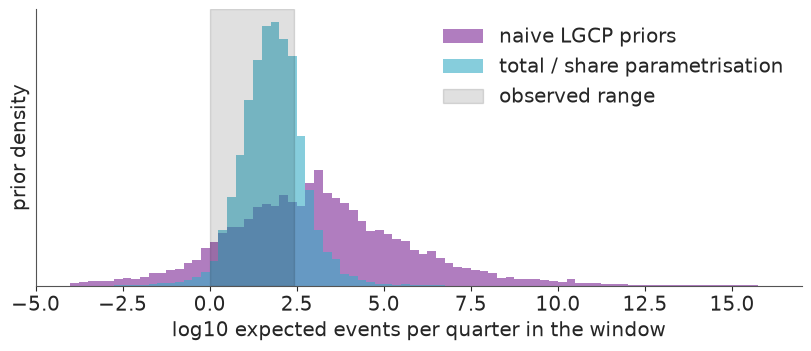

In [15]:
fig, ax = plt.subplots(figsize=(8, 3.4))
bins = np.linspace(-4, 16, 81)
ax.hist(naive_log10, bins=bins, density=True, alpha=0.6, color="C3", label="naive LGCP priors")
ax.hist(fixed_log10, bins=bins, density=True, alpha=0.6, color="C0", label="total / share parametrisation")
ax.axvspan(0, np.log10(float(y_train.sum("cell").max())), color="k", alpha=0.12, label="observed range")
ax.set(xlabel="log10 expected events per quarter in the window", ylabel="prior density", yticks=[])
ax.legend();

The new prior is still broad - it has to be, for a rate that really did rise more than a
hundredfold - but it lives on the right planet: quarterly totals from a couple to about a
thousand, maps in which most cell-quarters are empty, and a largest count somewhere between
a handful and a few thousand. The upper tail remains generous, but the observed values sit
inside the central 90% of every row, and nothing is off by ten orders of magnitude.

## 5 · Rung 1: time only

Every cell gets the same share, $1/108$. The helper below samples a rung and reports the
diagnostics we will want each time.

In [16]:
HYPERS = ["alpha", "sigma_g", "ell", "eta0", "eta_d", "inv_phi"]


loo_ready = {}  # rung name -> PSIS-LOO result, for section 9


def fit(name, kind, likelihood="poisson", draws=1000):
    with build_model(kind, likelihood):
        idata = pm.sample(draws=draws, random_seed=RANDOM_SEED)
        # PSIS-LOO on at most 1000 draws per chain. Keep only the small result: the thinned copy
        # of the fit, its log-likelihood and the importance weights ArviZ stores on the result
        # are hundreds of MB per rung, and this notebook fits four of them.
        thinned = idata.isel(draw=slice(None, None, draws // 1000))
        pm.compute_log_likelihood(thinned, progressbar=False)
        loo_ready[name] = az.loo(thinned, pointwise=True)
        loo_ready[name].log_weights = None
        del thinned
    latent = az.summary(idata, var_names=[v for v in ["g", "field"] if v in idata.posterior])
    print(f"sampling: {idata.posterior.attrs.get('sampling_time', float('nan')):.0f}s   "
          f"divergences: {int(idata.sample_stats['diverging'].sum())}   "
          f"g / field: max r_hat {latent.r_hat.max():.3f}, min bulk ESS {latent.ess_bulk.min():.0f}")
    return idata


def hyper_summary(idata):
    return az.summary(idata, var_names=[v for v in HYPERS if v in idata.posterior],
                      ci_kind="hdi", ci_prob=0.94, round_to=2)


time_idata = fit("1 time only", "time")
hyper_summary(time_idata)

NUTS[nutpie]: [alpha, sigma_g, step]


sampling: 1s   divergences: 0   g / field: max r_hat 1.003, min bulk ESS 2295


/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/arviz_stats/loo/loo_helper.py:1170: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha,3.31,0.05,3.21,3.41,3798.69,3103.09,1.0,0.0,0.0
sigma_g,0.73,0.11,0.52,0.93,1872.01,2410.93,1.0,0.0,0.0


No divergences, `r_hat` of 1.00. To look at predictions we need the expected counts
$\mu_{ct}$ for **all** 44 quarters and simulated counts around them. Because the future
innovations are in the posterior, one helper serves both the in-sample replicates and the
forecast. It is written with xarray so that the era-to-quarter lookup is done by label, and
it thins to 1000 draws to keep the arrays small.

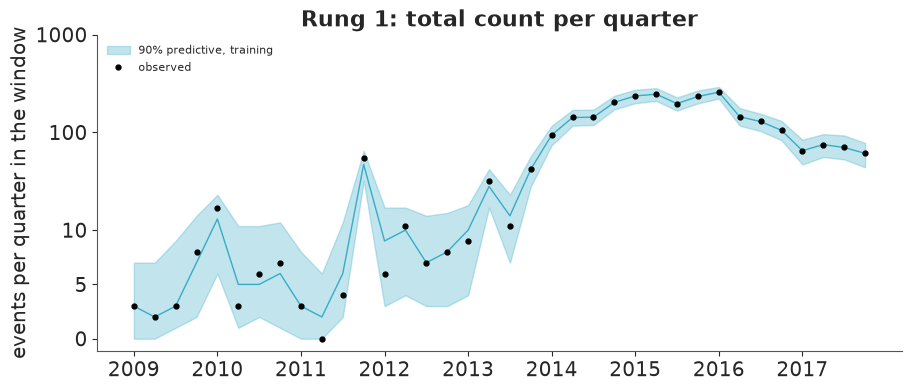

In [17]:
def expected_counts(idata, kind, n_draws=1000):
    """Posterior draws of mu with dims (cell, period, sample), all 44 quarters."""
    post = az.extract(idata, num_samples=n_draws, random_seed=RANDOM_SEED)
    log_total = post["alpha"] + post["g"]
    if kind == "time":
        log_share = xr.DataArray(np.full(n_cell, -np.log(n_cell)), dims="cell", coords={"cell": counts.cell})
    else:
        f = post["field"] - post["field"].max("cell")
        log_share = f - np.log(np.exp(f).sum("cell"))
        if kind == "interaction":
            log_share = log_share.sel(era=era_of_period)
    mu = np.exp(log_total + log_share).transpose("cell", "period", "sample")
    return mu.assign_coords(year=("period", year_of_period)), post


def simulate(idata, kind, likelihood="poisson"):
    """Expected counts and one simulated count array per posterior draw."""
    mu, post = expected_counts(idata, kind)
    if likelihood == "poisson":
        sims = rng.poisson(mu.to_numpy())
    else:
        n = 1 / post["inv_phi"].to_numpy()  # broadcasts over the trailing sample axis
        sims = rng.negative_binomial(n, n / (n + mu.to_numpy()))
        mu = mu.assign_coords(nb_size=("sample", n))  # keep each draw's dispersion next to its mu
    return mu, xr.DataArray(sims, dims=mu.dims, coords=mu.coords)


def plot_totals(y_rep, ax, title, forecast=False):
    total = y_rep.sum("cell")
    lo, mid, hi = total.quantile([0.05, 0.5, 0.95], dim="sample").to_numpy()
    t = np.arange(n_period)
    obs = counts.sum("cell").to_numpy()
    pieces = [(slice(0, n_train), "C0", "90% predictive, training")]
    if forecast:
        pieces.append((slice(n_train - 1, None), "C1", "90% predictive, forecast"))
    for sl, color, label in pieces:
        ax.fill_between(t[sl], lo[sl], hi[sl], color=color, alpha=0.3, label=label)
        ax.plot(t[sl], mid[sl], color=color, lw=1)
    ax.plot(t[:n_train], obs[:n_train], "ko", ms=3.5, label="observed")
    if forecast:
        ax.plot(t[n_train:], obs[n_train:], "o", ms=4.5, mfc="w", mec="k", label="held out")
    ax.set_yscale("symlog", linthresh=10)
    ax.set_yticks([0, 5, 10, 100, 1000], labels=["0", "5", "10", "100", "1000"])
    last = n_period if forecast else n_train
    ax.set_xticks(t[:last:4], labels=years[: last // 4])
    ax.set(ylabel="events per quarter in the window", title=title)


time_mu, time_rep = simulate(time_idata, "time")

fig, ax = plt.subplots(figsize=(9, 3.8))
plot_totals(time_rep, ax, "Rung 1: total count per quarter")
ax.legend(fontsize=8, loc="upper left");

In [18]:
def share_empty(y_rep):
    """Share of empty cell-quarters in the training period, per posterior draw."""
    return (y_rep.isel(period=slice(0, n_train)) == 0).mean(("cell", "period"))


obs_empty = float((y_train == 0).mean())
lo, hi = share_empty(time_rep).quantile([0.03, 0.97]).to_numpy()
print(f"share of empty cell-quarters: observed {obs_empty:.3f}, rung 1 predicts {lo:.3f} - {hi:.3f}")

share of empty cell-quarters: observed 0.862, rung 1 predicts 0.619 - 0.648


The temporal check passes almost by construction: a random walk with one free value per
quarter can follow any series of totals (the axis is linear below 10 and logarithmic
above). Note the spike in late 2011 - the Prague sequence, a mainshock with its aftershocks.
The model can only read that as a sudden rise and fall of the background rate.

The spatial check fails completely. Spreading events evenly over 108 cells predicts far
fewer empty cells than the 86% observed. On to space.

## 6 · Rung 2: separable space + time

In [19]:
sep_idata = fit("2 separable", "separable")
hyper_summary(sep_idata)

NUTS[nutpie]: [alpha, sigma_g, step, ell, eta0, z]


/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/arviz_stats/loo/loo_helper.py:1170: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


sampling: 6s   divergences: 0   g / field: max r_hat 1.003, min bulk ESS 1943


,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha,3.31,0.05,3.22,3.42,4602.82,3244.43,1.0,0.00,0.00
sigma_g,0.72,0.11,0.53,0.94,1874.57,2388.97,1.0,0.00,0.00
ell,29.34,3.83,22.20,36.66,1203.43,1718.90,1.0,0.11,0.06
eta0,3.74,0.53,2.77,4.67,1213.53,1598.89,1.0,0.02,0.01


Fast and clean. `eta0` is large - the log-intensity varies across the map with a standard
deviation approaching 4, i.e. the busiest places are thousands of times more active than
the quietest - and the lengthscale is short, about 30 km: not much more than one cell.
Both are as the maps suggested, and $\ell$ is in the range where our `m` and `c` are accurate.

Is one fixed map enough? Compare observed yearly counts with the model's expectation:

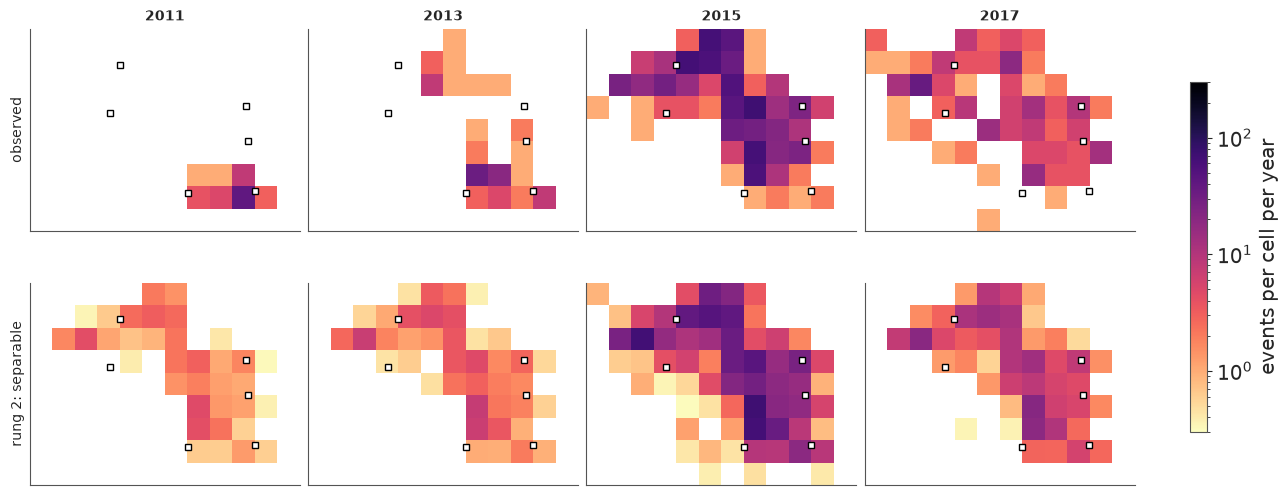

In [20]:
def yearly_mean(mu):
    """Posterior mean of expected events per cell per year: dims (year, cell)."""
    return mu.mean("sample").groupby("year").sum().transpose("year", "cell")


def compare_maps(panels, show_years):
    """panels: list of (row label, (year, cell) array or None for the observed counts)."""
    fig, axes = plt.subplots(len(panels), len(show_years), figsize=(3.2 * len(show_years), 2.55 * len(panels)),
                             squeeze=False)
    for i, (label, arr) in enumerate(panels):
        for j, year in enumerate(show_years):
            vals = yearly.sel(year=year) if arr is None else arr.sel(year=year)
            mesh = draw_map(axes[i, j], faint_to_blank(vals), f"{year}" if i == 0 else None, COUNT_NORM)
        axes[i, 0].set_ylabel(label, fontsize=10)
    fig.colorbar(mesh, ax=axes, label="events per cell per year", shrink=0.7)


sep_mu, sep_rep = simulate(sep_idata, "separable")
compare_maps([("observed", None), ("rung 2: separable", yearly_mean(sep_mu))], [2011, 2013, 2015, 2017])

The separable model paints the **same picture every year** and only turns the brightness
up and down. It puts the 2011 Prague sequence on a faint copy of the 2015 map, predicts
activity in the north-west years before there was any, and keeps the south-east glowing in
2017. The time-averaged map is a fair summary of nine years and a poor description of any
one of them. That is what "no interaction" means.

## 7 · Rung 3: letting the hot-spot move

We need $f$ to depend on time. Options, and why we choose the one we do:

| option | coefficients | verdict |
|---|---|---|
| 3-D HSGP over $(x, y, t)$ - for a product kernel, a Kronecker product of the spatial basis with a temporal sine basis | $m_x m_y m_t$ | stationary in time: one temporal lengthscale and one amplitude for the whole record, and forecasts that revert to the long-run map. With $m_t \approx 15$, about 2100 coefficients |
| independent field per year | $m_x m_y \times 11$ | no memory: nothing to forecast with, and 2009 (20 events) must be learned from scratch |
| **random walk over yearly fields** | $m_x m_y \times 11 = 1540$ | this year's map is last year's plus a smooth increment: borrows strength across years, is non-stationary (a process that *switched on* is not stationary), and extends forward by construction |

Yearly rather than quarterly eras keep the parameter count down by a factor of four; the
quarter-to-quarter changes in the *total* are still carried by $g_t$. The price is that the
map can only change on 1 January.

We fit it first with the Poisson likelihood of the textbook LGCP.

In [21]:
int_idata = fit("3 interaction", "interaction")
hyper_summary(int_idata)

NUTS[nutpie]: [alpha, sigma_g, step, ell, eta0, eta_d, z]


/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/arviz_stats/loo/loo_helper.py:1170: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


sampling: 8s   divergences: 0   g / field: max r_hat 1.012, min bulk ESS 435


,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha,3.31,0.05,3.22,3.42,1811.41,2375.64,1.00,0.00,0.00
sigma_g,0.72,0.11,0.52,0.91,1134.58,1811.49,1.00,0.00,0.00
ell,27.19,2.60,22.50,32.17,357.98,724.57,1.01,0.14,0.07
eta0,3.46,0.43,2.67,4.25,352.54,624.49,1.01,0.02,0.01
eta_d,1.59,0.14,1.34,1.87,740.67,1048.53,1.00,0.01,0.00


1540 field coefficients, a few seconds of sampling, no divergences and `r_hat` at 1.00-1.01.
The GP hyperparameters `ell` and `eta0` mix most slowly (bulk ESS of a few hundred); that is
enough for a stepping stone, and we will run the final model for longer.

`eta_d` says the log-intensity at a typical location changes by about 1.6 **per year** - a
factor of five up or down - and that is in the upper tail of its `HalfNormal(1)` prior: the
data insist. The map is not drifting, it is being redrawn.

### Is Poisson enough?

Conditional on $\lambda$, an LGCP assumes events are independent. Earthquakes are not:
they trigger aftershocks, so events arrive in bursts that are tighter in space and time
than any smooth field. Check two statistics the Poisson likelihood constrains only
indirectly - the share of empty cell-quarters and the largest single count:

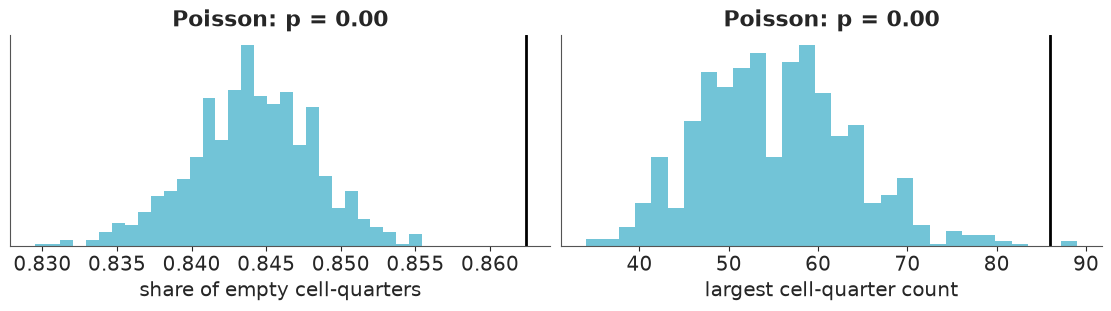

In [22]:
int_mu, int_rep = simulate(int_idata, "interaction")


def dispersion_check(reps, axes):
    stats_obs = [float((y_train == 0).mean()), int(y_train.max())]
    for ax_row, (label, y_rep) in zip(axes, reps.items()):
        y_in = y_rep.isel(period=slice(0, n_train))
        draws_list = [share_empty(y_rep), y_in.max(("cell", "period"))]
        names = ["share of empty cell-quarters", "largest cell-quarter count"]
        for ax, draws, obs, name in zip(ax_row, draws_list, stats_obs, names):
            ax.hist(draws, bins=30, color="C0", alpha=0.7)
            ax.axvline(obs, color="k", lw=2)
            ax.set(yticks=[], xlabel=name, title=f"{label}: p = {float((draws >= obs).mean()):.2f}")


fig, axes = plt.subplots(1, 2, figsize=(11, 3), squeeze=False)
dispersion_check({"Poisson": int_rep}, axes)

Each title gives $p$, the share of replicated datasets in which the statistic is at least
as large as observed. Both checks fail, in the same direction. Replicated datasets have
**too few empty cells** and **hardly ever a count as large as the observed 86**: the real
events are more clumped than a Poisson process with this smooth intensity. The field has
done what it could to absorb the clumps - remember how rough and volatile it came out - but
a smooth surface cannot produce a burst in one cell in one quarter.

### Rung 4: negative binomial counts

$y_{ct} \sim \text{NegBinomial}(\mu_{ct}, \phi)$ has variance $\mu + \mu^2/\phi$. We
put the prior on $1/\phi$ (`inv_phi ~ Exponential(1)`), so that the Poisson model is the
point $1/\phi = 0$ rather than $\phi = \infty$. Think of it as a crude stand-in for
aftershock clustering: it says bursts happen, without saying when or where.

In [23]:
# 3000 draws per chain instead of the default 1000: ell and eta0 mix slowly (see below)
nb_idata = fit("4 interaction + NegBin", "interaction", "negbin", draws=3000)
hyper_summary(nb_idata)

NUTS[nutpie]: [alpha, sigma_g, step, ell, eta0, eta_d, z, inv_phi]


/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/arviz_stats/loo/loo_helper.py:1170: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


sampling: 59s   divergences: 0   g / field: max r_hat 1.005, min bulk ESS 1082


,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha,3.40,0.07,3.25,3.54,5243.43,6833.90,1.00,0.00,0.00
sigma_g,0.48,0.10,0.32,0.67,1520.74,2556.72,1.00,0.00,0.00
ell,35.69,3.87,28.59,42.97,778.63,1494.33,1.00,0.14,0.06
eta0,3.58,0.51,2.68,4.58,706.23,1310.79,1.01,0.02,0.01
eta_d,1.42,0.15,1.16,1.72,2151.95,3700.65,1.00,0.00,0.00
inv_phi,0.79,0.09,0.63,0.96,7091.01,7483.27,1.00,0.00,0.00


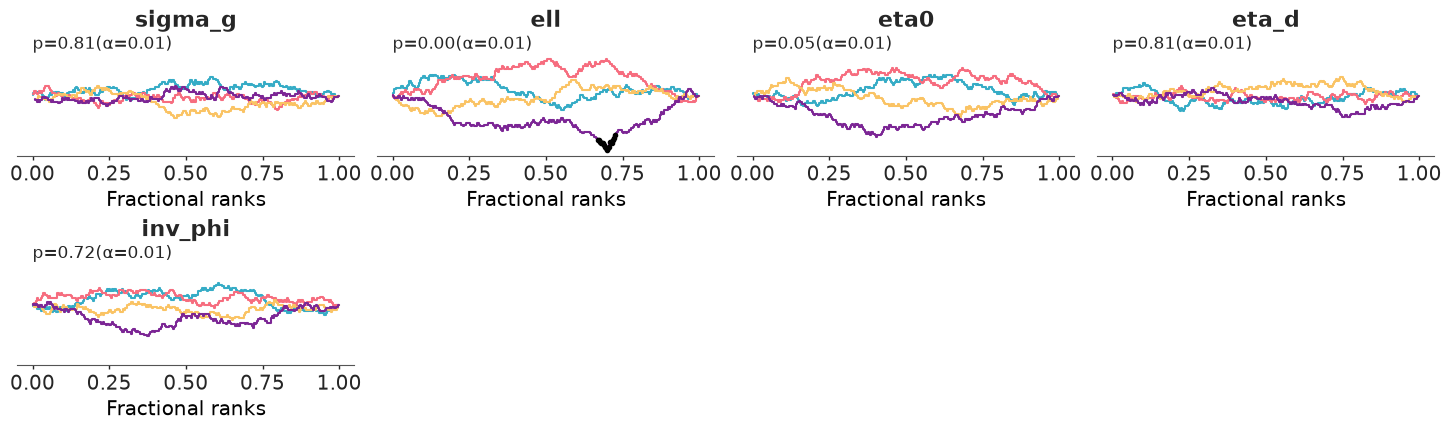

In [24]:
# the envelope of the rank plot assumes independent draws, so thin the autocorrelated chains first
thinned = nb_idata.isel(draw=slice(None, None, 10))
az.plot_rank(thinned, var_names=["sigma_g", "ell", "eta0", "eta_d", "inv_phi"]);

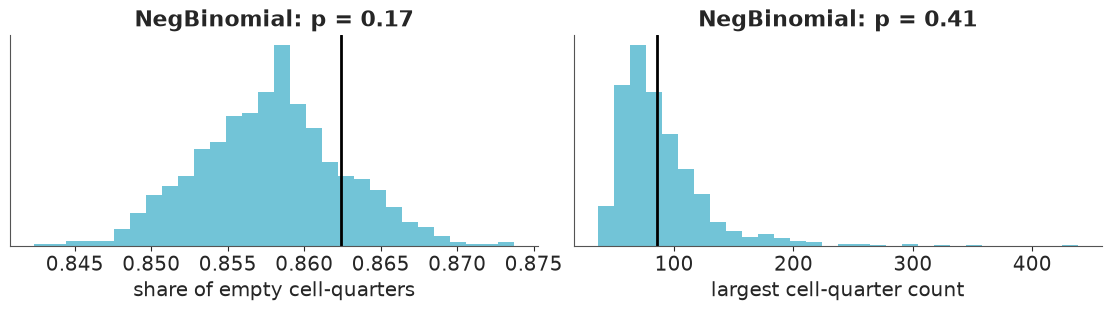

In [25]:
nb_mu, nb_rep = simulate(nb_idata, "interaction", "negbin")

fig, axes = plt.subplots(1, 2, figsize=(11, 3), squeeze=False)
dispersion_check({"NegBinomial": nb_rep}, axes)

In [26]:
pd.concat({"rung 3 (Poisson)": hyper_summary(int_idata)["mean"],
           "rung 4 (NegBinomial)": hyper_summary(nb_idata)["mean"]}, axis=1)

,rung 3 (Poisson),rung 4 (NegBinomial)
alpha,3.31,3.40
sigma_g,0.72,0.48
ell,27.19,35.69
eta0,3.46,3.58
eta_d,1.59,1.42
inv_phi,NaN,0.79


No divergences, `r_hat` of 1.00-1.01 for every hyperparameter and for the whole field. This
is the stickiest fit of the notebook: `ell` and `eta0` trade off against each other and
against all 1540 coefficients at once (a longer lengthscale with a larger amplitude gives a
similar field), so their bulk ESS is 700-800 out of 12,000 draws, against thousands for
the rest. That is why this rung gets 3000 draws per chain.

The rank plot tells the same story. (Its envelope assumes independent draws, so we thin the
chains first; unthinned, every slowly mixing parameter is flagged however long you run.)
Four panels stay inside the 99% envelope. `ell` does not quite: one chain spent less time
at short lengthscales than the others and touches the edge (black marks). With
`r_hat` at 1.00 that is slow mixing rather than chains disagreeing about where the posterior
is - adequate for the maps and intervals below, but run longer if a hyperparameter is itself
what you want to report.

`inv_phi` is far from zero: the data want the extra variance, and both predictive checks now
pass. Compare the two columns of the last table for what that did to the rest of the model.
With bursts handled by the likelihood, the field relaxes: a longer lengthscale (about 36 km
instead of 27) and smaller yearly increments, and the random walk for the total takes smaller
steps (`sigma_g`) because a quarter like 2011 Q4 no longer has to be explained by the
background rate alone. **An overdispersed likelihood is a regulariser for the latent field.**
The posterior of $\ell$ stays well below 50 km, where the `m=[14, 10], c=1.5` approximation
was shown to be accurate, so the obligation from section 3 is discharged.

## 8 · Answers: where, when, and how it moved

The posterior mean of the expected number of events per cell per year, with the actual
epicentres on top (blue dots):

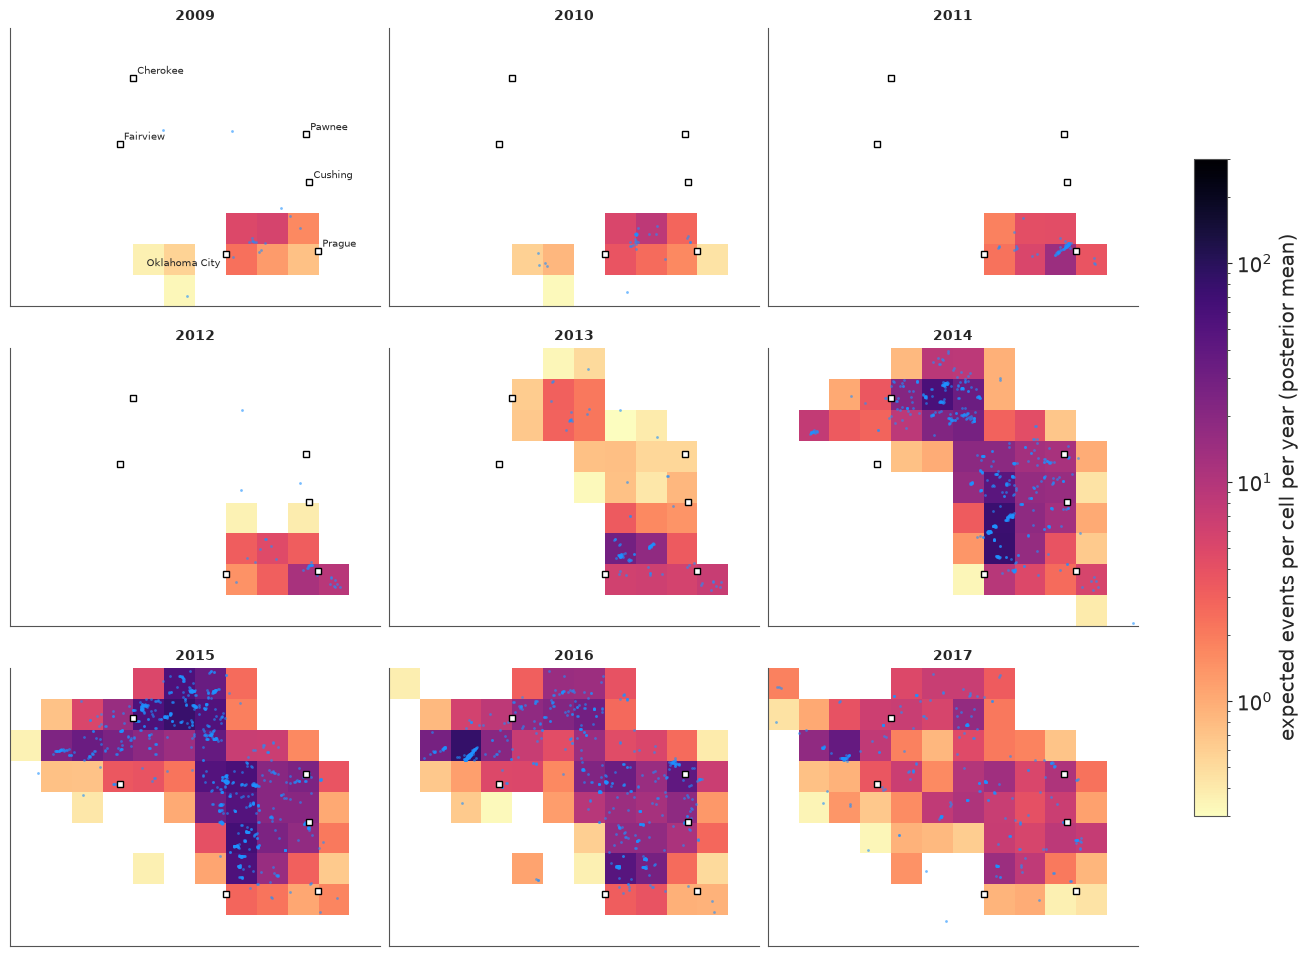

In [27]:
nb_yearly = nb_mu.groupby("year").sum()  # (cell, sample, year)
nb_yearly_mean = nb_yearly.mean("sample").transpose("year", "cell")

fig, axes = plt.subplots(3, 3, figsize=(13, 9.6))
for ax, year in zip(axes.flat, years[:9]):
    mesh = draw_map(ax, faint_to_blank(nb_yearly_mean.sel(year=year)), str(year), COUNT_NORM,
                    labels=(year == 2009), pts=events[events.time.dt.year == year])
fig.colorbar(mesh, ax=axes, label="expected events per cell per year (posterior mean)", shrink=0.7);

**Where and when:** a faint patch east of Oklahoma City in 2009-10; the Prague sequence in
2011-12; in 2013 a new centre north-east of Oklahoma City and a first, separate patch near
the Kansas border; in 2014-15 both grow and merge into a band from Oklahoma City to the
border, with an arm reaching west past Cherokee; from 2016 the whole map dims. The brightest
cell of 2016-17 lies north-west of Fairview, which is where the catalogue places the
magnitude-5.1 event of February 2016. White cells have fewer than 0.3 expected events a year.

A mean is half an answer. The map of **uncertainty** - here the posterior standard
deviation of the log expected count - is just as informative:

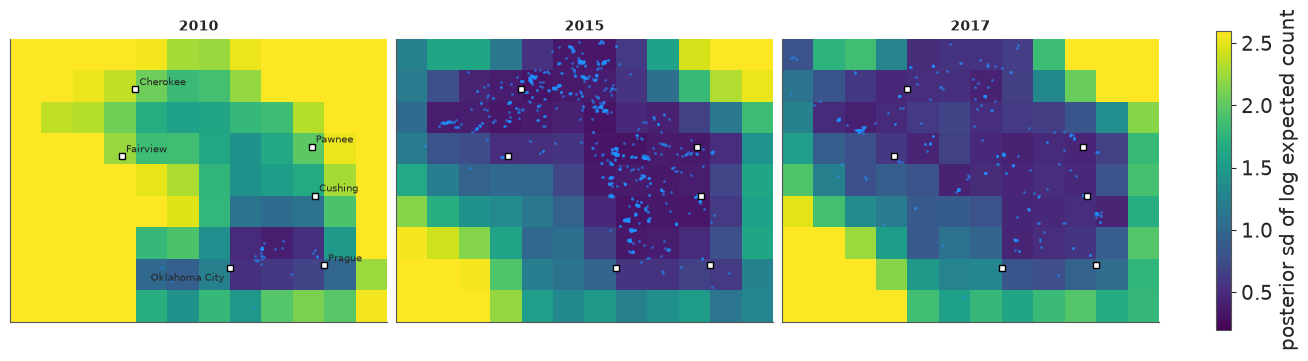

In [28]:
nb_log_sd = np.log(nb_yearly).std("sample").transpose("year", "cell")

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, year in zip(axes, [2010, 2015, 2017]):
    mesh = draw_map(ax, nb_log_sd.sel(year=year), str(year), cmap="viridis", labels=(year == 2010),
                    pts=events[events.time.dt.year == year])
    mesh.set_clim(0.2, 2.6)
fig.colorbar(mesh, ax=axes, label="posterior sd of log expected count", shrink=0.85);

The pattern is the mirror image of the intensity map. Where there are events the field is
pinned down to a fraction of a log unit; in empty regions all the data say is "low", and
*how* low is left to the prior - an sd of 2 on the log scale means "somewhere between very
few and almost none". That is the right kind of ignorance, and it is worth showing to
anyone tempted to read the blank cells of the mean map as a precise zero. In 2010 - a few
dozen events, and five random-walk steps away from the anchor year - everything outside the
patch near Oklahoma City is uncertain, much of it beyond the 2.6 at which the colour scale
is capped.

**How did the hot-spot move?** Summarise each year's map by its centre of mass,
$\sum_c \pi_{c,e}\, s_c$, a derived quantity with a full posterior. The observed
counterpart is the centroid of that year's events (by cell centre, to compare like with like).

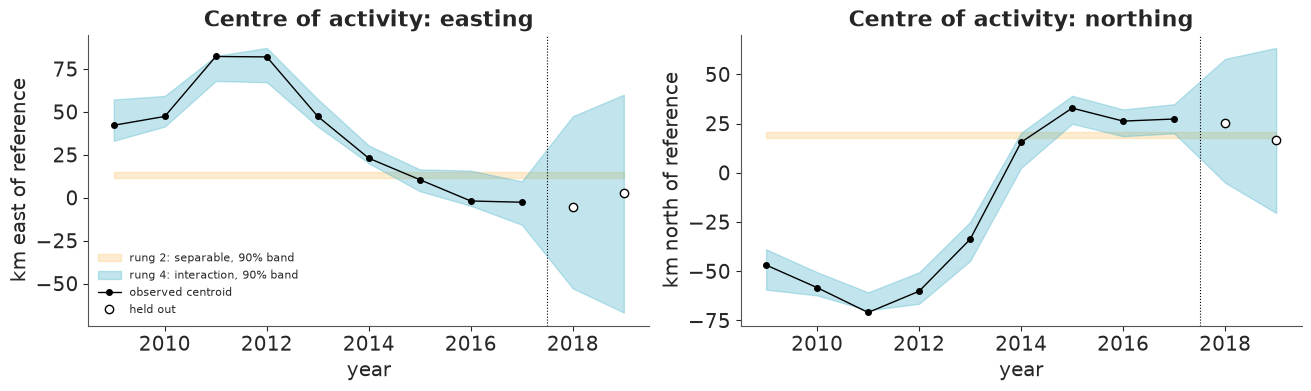

In [29]:
def centroid_track(mu):
    yearly_mu = mu.groupby("year").sum()
    share = yearly_mu / yearly_mu.sum("cell")
    return (share * counts.x).sum("cell"), (share * counts.y).sum("cell")


obs_share = yearly / yearly.sum("cell")
obs_track = (obs_share * counts.x).sum("cell"), (obs_share * counts.y).sum("cell")

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8), sharex=True)
for mu, color, label in [(sep_mu, "C2", "rung 2: separable"), (nb_mu, "C0", "rung 4: interaction")]:
    for ax, track in zip(axes, centroid_track(mu)):
        lo, hi = track.quantile([0.05, 0.95], dim="sample").to_numpy()
        ax.fill_between(years, lo, hi, color=color, alpha=0.3, label=f"{label}, 90% band")
for ax, obs, name in zip(axes, obs_track, ["east", "north"]):
    ax.plot(years[:9], obs.sel(year=years[:9]), "ko-", ms=4, lw=1, label="observed centroid")
    ax.plot(years[9:], obs.sel(year=years[9:]), "o", mfc="w", mec="k", label="held out")
    ax.axvline(2017.5, color="k", lw=0.8, ls=":")
    ax.set(xlabel="year", ylabel=f"km {name} of reference", title=f"Centre of activity: {name}ing")
axes[0].legend(fontsize=8, loc="lower left");

In [30]:
track_x, track_y = centroid_track(nb_mu)
moves = pd.DataFrame({"east (km)": track_x.mean("sample").to_numpy(),
                      "north (km)": track_y.mean("sample").to_numpy()}, index=years)
print(moves.loc[[2011, 2015, 2017]].round(0).to_string())
shift = np.hypot(track_x.sel(year=2015) - track_x.sel(year=2011),
                 track_y.sel(year=2015) - track_y.sel(year=2011))
print(f"\ndistance moved by the centre of activity 2011 -> 2015: {float(shift.mean()):.0f} km "
      f"(90% interval {float(shift.quantile(0.05)):.0f} - {float(shift.quantile(0.95)):.0f} km)")

      east (km)  north (km)
2011       76.0       -66.0
2015       10.0        32.0
2017       -2.0        28.0

distance moved by the centre of activity 2011 -> 2015: 117 km (90% interval 106 - 128 km)


The interaction model follows the observed centroid year by year, with wider bands in the
sparse early years and tight ones at the peak. Between the Prague year and the 2015 peak the
centre of activity moved well over 100 km to the north-west - some 65 km west and 100 km
north, as printed above - and then barely moved while the rate fell. The separable model, by
construction, has a single centroid for all years (its band is flat). To the right of the
dotted line the bands are *forecasts*; they open up quickly, which is the subject of section
10.

### Spatial posterior predictive check

The same observed-versus-expected maps as in section 6, now with rung 4 added:

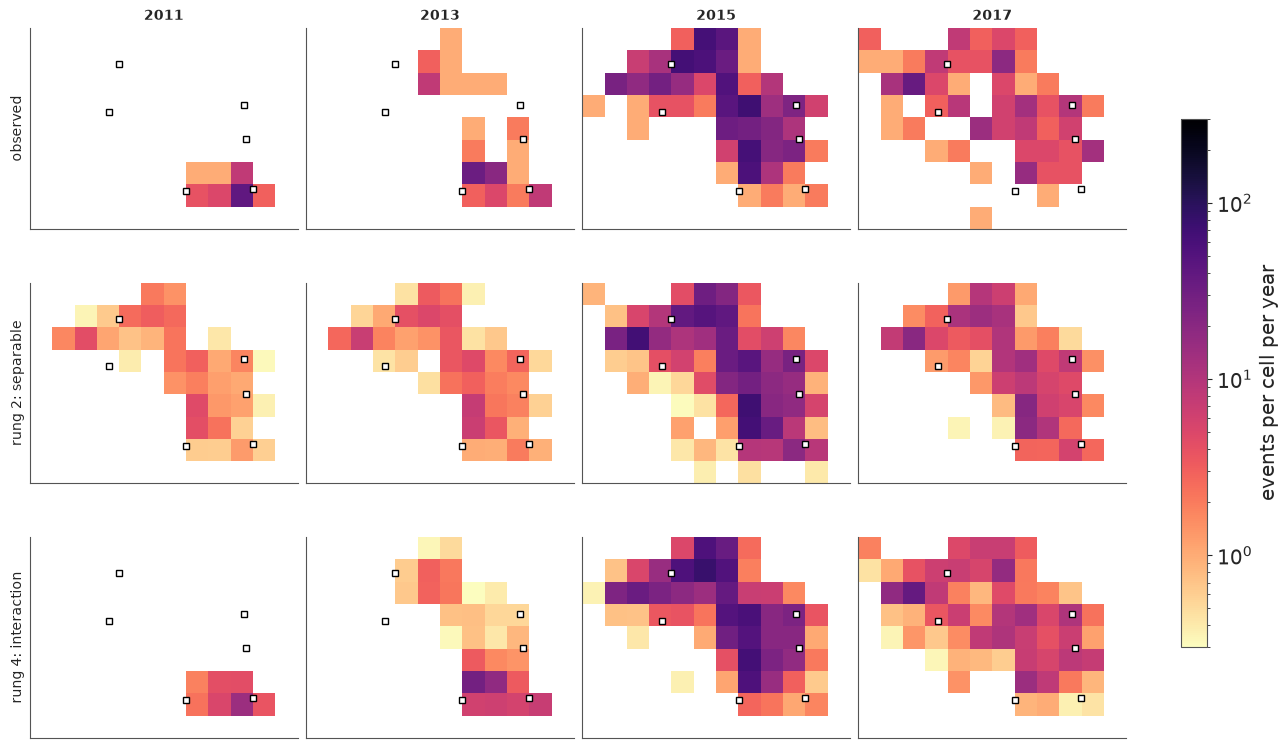

In [31]:
compare_maps([("observed", None), ("rung 2: separable", yearly_mean(sep_mu)),
              ("rung 4: interaction", nb_yearly_mean)], [2011, 2013, 2015, 2017])

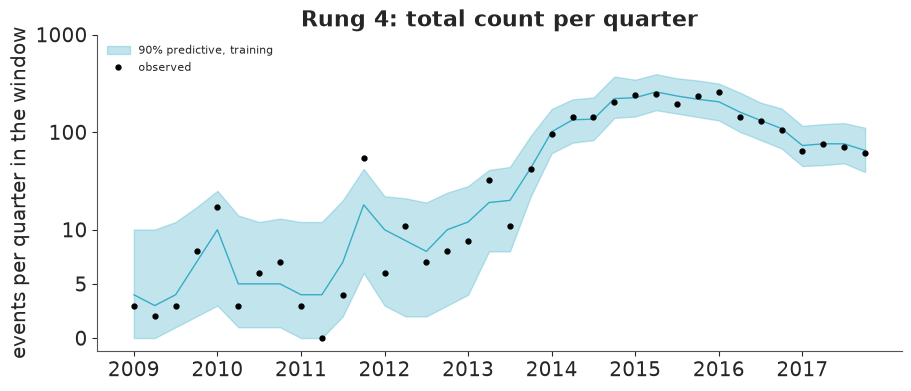

In [32]:
fig, ax = plt.subplots(figsize=(9, 3.8))
plot_totals(nb_rep, ax, "Rung 4: total count per quarter")
ax.legend(fontsize=8, loc="upper left");

Rung 4 reproduces each year's map, including the isolated Prague cluster in 2011 and the
contraction by 2017, and the temporal check still passes. Its bands for the quarterly
totals are wider than rung 1's: the negative binomial admits that a quarter's count is
noisier than Poisson.

## 9 · Model comparison with LOO

In [33]:
comparison = az.compare(loo_ready, round_to=1)
comparison

,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
4 interaction + NegBin,0,0.0,0.0,NaN,,586 k̂ > 0.70,186.9,-1828.9,70.1,0.9
3 interaction,1,-323.6,45.8,1.0,,714 k̂ > 0.70,505.5,-2152.4,98.5,0.1
2 separable,2,-1171.6,178.4,1.0,,24 k̂ > 0.70,394.1,-3000.5,215.6,0.0
1 time only,3,-4200.3,383.1,1.0,,10 k̂ > 0.70,240.6,-6029.1,418.0,0.0


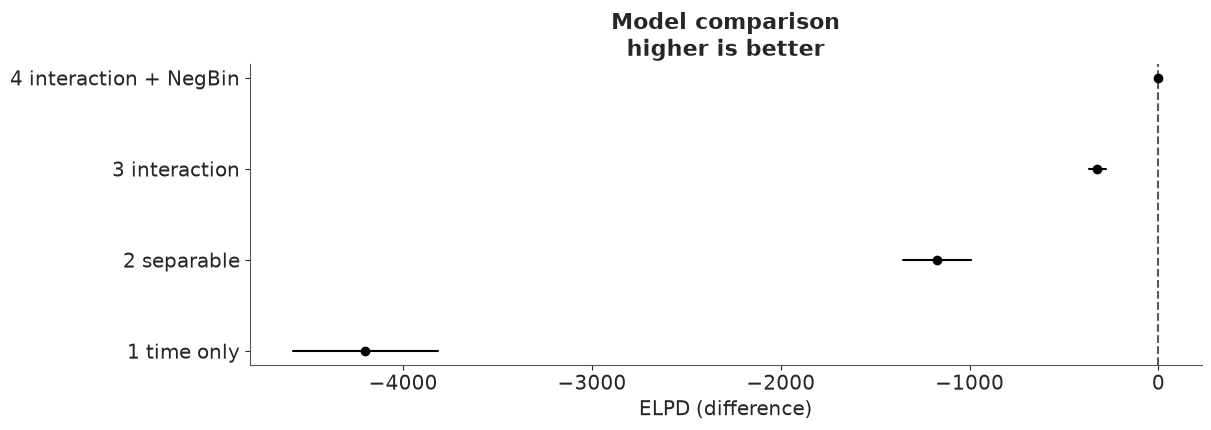

In [34]:
az.plot_compare(comparison);

Every rung is a large improvement on the last, by many multiples of `dse`. The biggest
step is adding space at all, the next is letting the map move, and the negative binomial
is worth several hundred more - while *reducing* the effective number of parameters `p`
by almost two thirds. That is the regularisation we saw in the hyperparameters, showing up
as predictive accuracy: the Poisson field was fitting bursts as if they were signal.

Now the small print. ArviZ warns about Pareto-$k$ values above 0.7, and the `diag_elpd`
column shows that for the two interaction rungs this is not a handful of points but
hundreds of the 3888. That is the price of a very flexible latent field with a short
lengthscale: each non-empty cell-quarter has a strong pull on its own neighbourhood, so the
posterior without that observation would differ noticeably - the case importance sampling
handles badly - and the `elpd` of rungs 3 and 4 is probably optimistic. Gaps of hundreds
and thousands leave the *ranking* in little doubt, but the numbers should not be quoted to
the last digit. The remedy is K-fold cross-validation (`az.loo_kfold`), ideally leaving out
whole blocks of neighbouring cells; at a minute per fit we skip it here, because we have
something better than any in-sample estimate: data the models have never seen.

## 10 · Forecasting the held-out years

No new machinery is needed. The innovations of 2018-19 - eight steps of $g$ and two yearly
increments of the field - were sampled along with everything else, from their priors given
each draw's `sigma_g`, `eta_d` and $\ell$. `simulate` already returned all 44 quarters; so
far we only looked at the first 36.

Here the total/share parametrisation pays off a second time. In the textbook form
$\alpha + g_t + f_t(s)$, a field whose variance grows with the forecast horizon inflates
the expected total by $e^{\text{var}/2}$: the forecast number of earthquakes would rise
purely because the model is unsure *where* they will be. With normalised shares the total
is governed by $g_t$ alone.

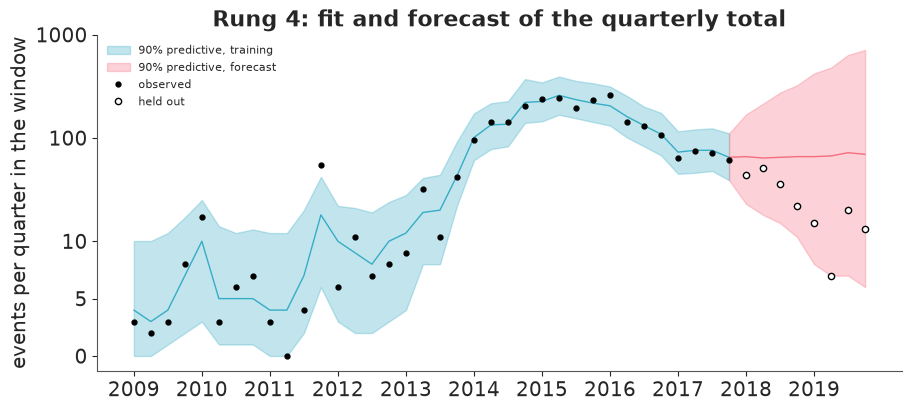

In [35]:
fig, ax = plt.subplots(figsize=(9, 4))
plot_totals(nb_rep, ax, "Rung 4: fit and forecast of the quarterly total", forecast=True)
ax.legend(fontsize=8, loc="upper left");

In [36]:
obs_test = y_test.to_numpy()
models = {"1 time only": (time_mu, time_rep), "2 separable": (sep_mu, sep_rep),
          "3 interaction": (int_mu, int_rep), "4 interaction + NegBin": (nb_mu, nb_rep)}

rows = {}
for name, (mu, y_rep) in models.items():
    mu_test = mu.isel(period=slice(n_train, None)).to_numpy()
    y_rep_test = y_rep.isel(period=slice(n_train, None))
    if "nb_size" in mu.coords:
        n = mu.nb_size.to_numpy()
        logp = stats.nbinom.logpmf(obs_test[..., None], n, n / (n + mu_test))
    else:
        logp = stats.poisson.logpmf(obs_test[..., None], mu_test)
    lpd = logsumexp(logp, axis=-1) - np.log(logp.shape[-1])  # log pointwise predictive density
    lo, hi = y_rep_test.quantile([0.05, 0.95], dim="sample").to_numpy()
    inside = (obs_test >= lo) & (obs_test <= hi)
    tot_lo, tot_mid, tot_hi = y_rep_test.sum("cell").quantile([0.05, 0.5, 0.95], dim="sample").to_numpy()
    obs_tot = obs_test.sum(0)
    rows[name] = {
        "hold-out log score": lpd.sum(),
        "2018": lpd[:, :4].sum(), "2019": lpd[:, 4:].sum(),
        "cells inside 90%": inside.mean(),
        "non-empty cells inside 90%": inside[obs_test > 0].mean(),
        "quarterly totals inside 90% (of 8)": int(((obs_tot >= tot_lo) & (obs_tot <= tot_hi)).sum()),
        "median forecast, 2 years": tot_mid.sum(),
    }
print(f"observed: {int(obs_test.sum())} events in 2018-19, {int((obs_test > 0).sum())} non-empty "
      f"cell-quarters out of {obs_test.size}")
pd.DataFrame(rows).T.round(2)

observed: 208 events in 2018-19, 106 non-empty cell-quarters out of 864


,hold-out log score,2018,2019,cells inside 90%,non-empty cells inside 90%,quarterly totals inside 90% (of 8),"median forecast, 2 years"
1 time only,-723.05,-389.23,-333.82,0.99,0.93,8.0,479.0
2 separable,-540.53,-296.47,-244.06,0.98,0.83,8.0,511.0
3 interaction,-418.24,-249.18,-169.07,0.99,0.93,8.0,470.0
4 interaction + NegBin,-415.81,-247.41,-168.40,0.99,0.92,8.0,535.5


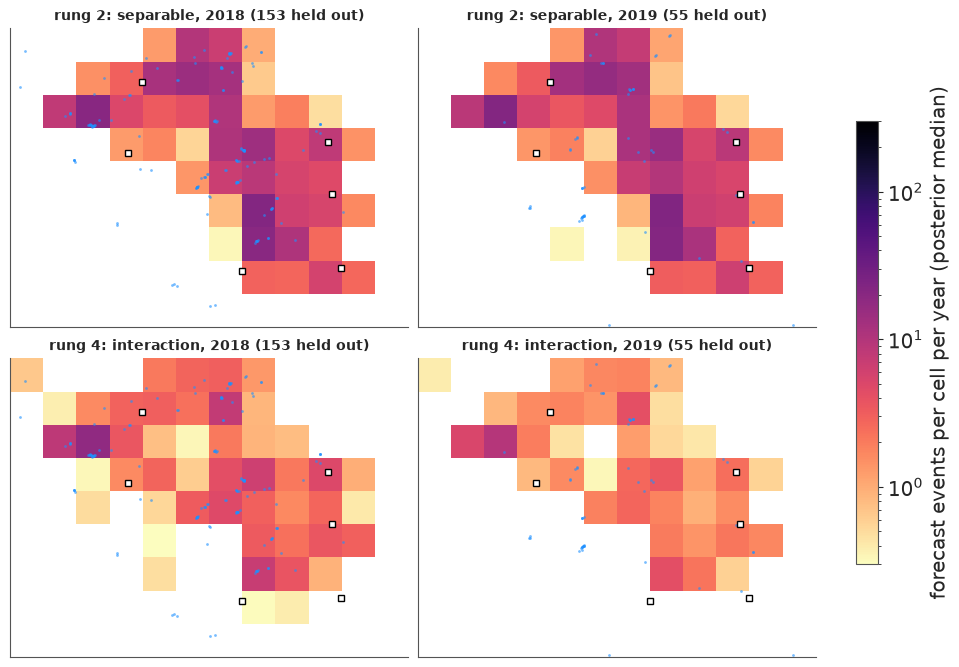

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(9.5, 6.6))
for ax_row, (label, mu) in zip(axes, [("rung 2: separable", sep_mu), ("rung 4: interaction", nb_mu)]):
    med = mu.groupby("year").sum().median("sample").transpose("year", "cell")
    for ax, year in zip(ax_row, [2018, 2019]):
        held_out = events[events.time.dt.year == year]
        mesh = draw_map(ax, faint_to_blank(med.sel(year=year)), f"{label}, {year} ({len(held_out)} held out)",
                        COUNT_NORM, pts=held_out)
fig.colorbar(mesh, ax=axes, label="forecast events per cell per year (posterior median)", shrink=0.7);

Read the table and the figures together.

**What the forecast gets right.**

- *Where.* The hold-out log score improves at every step from rung 1 to rung 3, in both
  years. The separable model forecasts with the nine-year average map, which still lights
  up areas that had gone quiet; the interaction model forecasts with the **latest** map,
  blurred by one and then two years of random-walk increments, and most held-out epicentres
  (blue) fall on it. LOO's ordering of rungs 1-3 is confirmed by genuinely unseen data.
- *Calibration of the totals.* Seven of the eight held-out quarterly totals lie inside
  rung 4's 90% band, and the eighth (the 7 events of 2019 Q2) is just below it.

**What deserves less credit.**

- Several small clusters of held-out events lie in the south-west of the window, on cells
  that both maps leave blank. A random walk can blur the last map; it cannot anticipate a
  new hot-spot.
- The 2019 map of rung 4 is paler than its 2018 map although the forecast total is the
  same. That is not a forecast of fewer earthquakes. The panels show the *median* of each
  cell, and as the model grows less sure where events will be, each cell's distribution
  spreads out and its median sinks. Summaries of skewed forecasts need care.
- Cell-level coverage of 99% for a nominal 90% is not a triumph: most cells are empty and
  an interval that starts at zero covers them trivially. The non-empty cells are the honest
  number, and there rungs 1, 3 and 4 are about right to slightly wide, while the separable
  model is too narrow - confident about the wrong map.
- Rungs 3 and 4 are practically **tied** on the hold-out, although LOO separated them by
  hundreds. The negative binomial earned its keep in the peak years, full of aftershock
  bursts; in a quiet period with a few events per cell there is little overdispersion to
  capture. LOO answers "which model describes data *like the training data*?", and 2018-19
  is not like the training data.
- The band for the total is **wide** - by late 2019 it spans two orders of magnitude - and
  the median forecast is flat at roughly the 2017 level, while the truth kept falling: the
  observed two-year total (208) is less than half of every model's median forecast, and the
  last quarters sit at the bottom of the band. A random walk has no notion of momentum: "it
  will stay where it is, give or take a lot" is the only forecast it can make.

### What this model cannot know

If the decline after 2015 was caused by the limits on injection, its cause lies outside the
catalogue. The model has **no covariate for injection**: it sees a rate that went up and then
down and extrapolates ignorance in both directions. Had injection resumed in 2018, the
forecast would have been exactly the same. It is a descriptive, *phenomenological* model -
excellent for mapping where and when the rate was elevated, with honest uncertainty, and for
short-range "more of the same" forecasts of where the next events will be. It is not a tool
for deciding what happens if policy changes. For that, the next step is mechanistic: put
injection volumes (lagged, and perhaps diffused in space) into $\log\lambda$ as a covariate,
and let the GP absorb only what the physics leaves unexplained.

### Try it yourself

1. **Magnitudes as marks.** The Gutenberg-Richter law says magnitudes above a completeness
   threshold are exponentially distributed: $m - 3 \sim \text{Exponential}(b \ln 10)$.
   Estimate the $b$-value (mind the rounding of magnitudes), then let it vary by year
   (hierarchically). Did the size distribution change as the rate rose and fell? Combine it
   with the rung-4 forecast to get the probability of at least one M4.5+ event in the window
   in 2018.
2. **Aftershocks, properly.** Replace the negative binomial's anonymous overdispersion by a
   self-exciting term: add $\kappa \cdot y_{c,t-1}$ (last quarter's count in the same cell,
   and perhaps its neighbours) to $\mu_{ct}$ - a discrete-time Hawkes/ETAS model. Does
   `inv_phi` shrink towards zero? Does the field get smoother still? Quarters are coarse for
   aftershock sequences: try months.
3. **Change the dynamics.** (a) Make the field increments mean-reverting (an AR(1) on the
   coefficients instead of a random walk) and compare hold-out scores. (b) Replace the random
   walk for $g$ with a local linear trend (a random walk on the *slope*) so that the forecast
   can carry the post-2015 decline forward - then ask whether you would have trusted the same
   model in 2013, when the slope pointed up. (c) If you can obtain injection volumes, add them
   as a covariate.

Next: the C-series challenges, where nobody tells you which rung to stop at.